In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/satellite_telemetry_train.csv')

In [ ]:
df.head()

,timestamp_min,solar_voltage,battery_temp,cpu_usage_pct,signal_strength_dbm,anomaly_flag
0,0,6.099343,NaN,48.084143,-70.976548,0
1,1,6.390886,35.173066,47.977965,-68.035356,0
2,2,6.964576,35.537375,65.634539,-68.559609,0
3,3,7.552076,35.679698,29.269532,-70.720557,0
4,4,7.606993,36.610334,49.235921,-69.186524,0


In [ ]:
df.isna().sum()

,0
timestamp_min,0
solar_voltage,0
battery_temp,22
cpu_usage_pct,0
signal_strength_dbm,0
anomaly_flag,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1287 entries, 0 to 1286
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp_min        1287 non-null   int64  
 1   solar_voltage        1287 non-null   float64
 2   battery_temp         1265 non-null   float64
 3   cpu_usage_pct        1287 non-null   float64
 4   signal_strength_dbm  1287 non-null   float64
 5   anomaly_flag         1287 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 60.5 KB


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.describe(include='all')

,timestamp_min,solar_voltage,battery_temp,cpu_usage_pct,signal_strength_dbm,anomaly_flag
count,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000,1265.000000
mean,643.226087,6.168305,33.924194,49.252722,-69.869576,0.163636
std,371.506816,4.985549,10.739972,17.317023,14.163778,0.370092
min,1.000000,0.000000,-273.000000,20.001843,-95.212741,0.000000
25%,322.000000,1.829229,27.802152,34.215999,-83.914033,0.000000
50%,643.000000,6.234654,34.344818,48.641024,-69.767168,0.000000
75%,965.000000,10.352877,40.610542,64.061941,-56.421761,0.000000
max,1286.000000,99.000000,44.539748,79.973462,-44.807739,1.000000


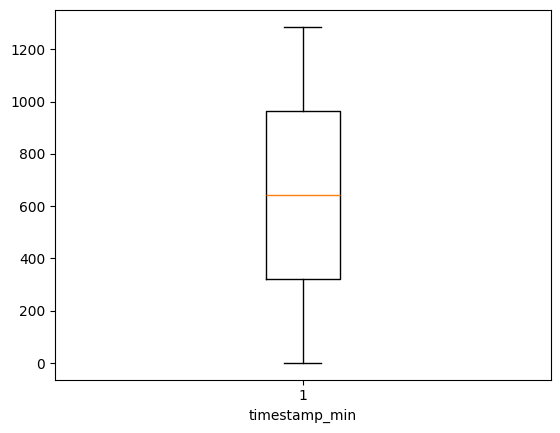

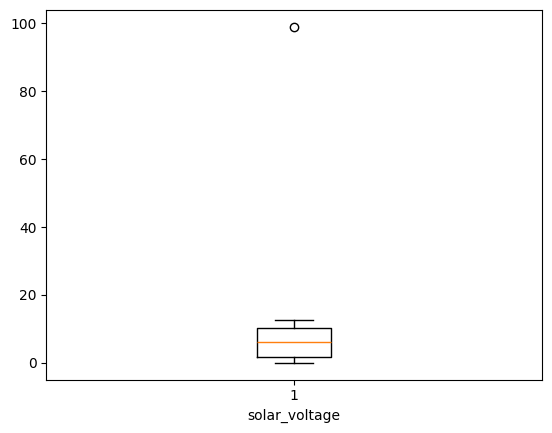

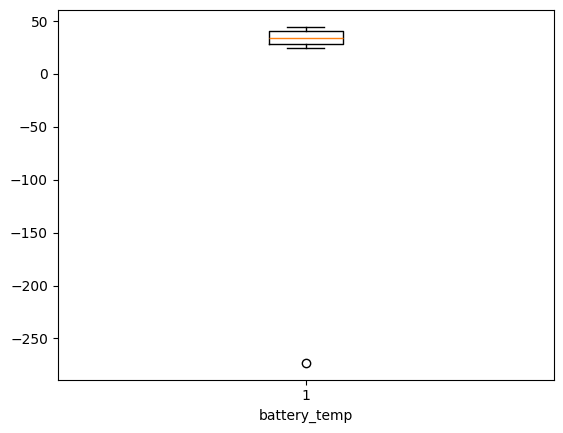

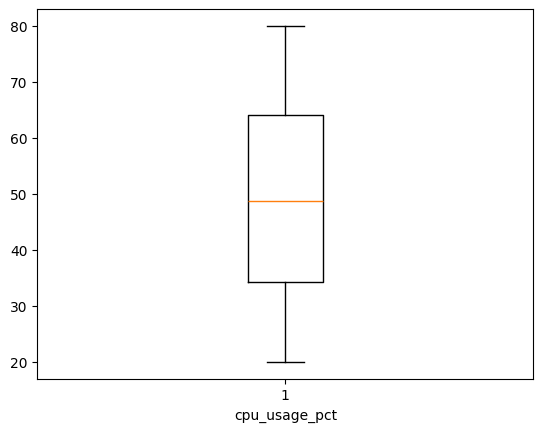

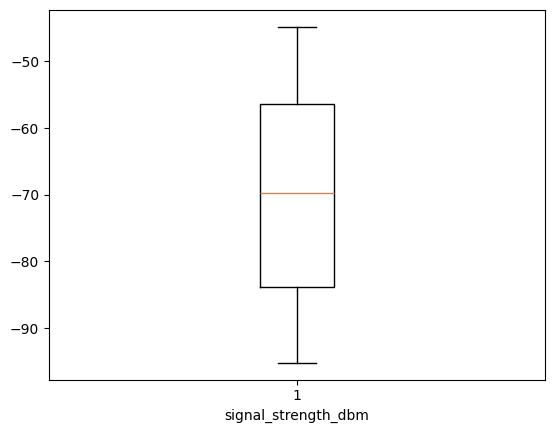

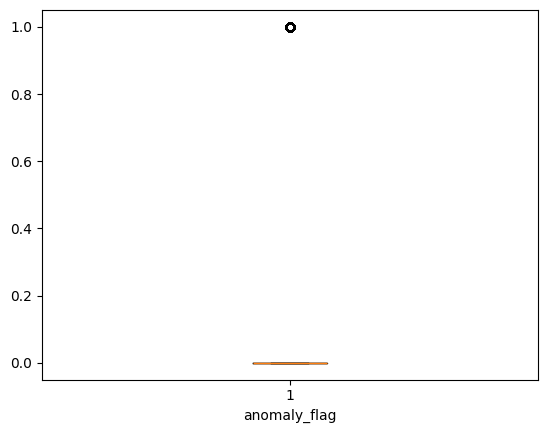

In [ ]:
for i in df.columns:
  if(df[i].dtype!='object'):
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()



In [ ]:
x=df.drop('anomaly_flag',axis=1)
y=df['anomaly_flag']

In [ ]:
df1=pd.read_csv('/content/satellite_telemetry_test.csv')
df1.dropna(inplace=True)
df1.drop_duplicates(inplace=True)
x1=df1.drop('anomaly_flag',axis=1)
y1=df1['anomaly_flag']
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x= scaler.fit_transform(x)
x1  = scaler.transform(x1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
n=x.shape[1]
w=np.zeros(n)
b=0.0

In [ ]:
def sigmoid(z):
  return 1/(1+np.exp(-z))


In [ ]:
def BCE (y,p):
  eps=1e-15
  p=np.clip(p, eps, 1-eps)
  return -np.mean(y*np.log(p)+(1-y)*np.log(1-p))

In [ ]:
l=1000
n=len(y)
for i in range(l):
  z=x@w +b
  p=sigmoid(z)
  loss=BCE(y,p)+0.01*np.sum(np.square(w))
  dw=(1/n)*(x.T@(p-y))+2*0.01*w
  db=(1/n)*np.sum(p-y)
  w=w-0.1*dw
  b=b-0.1*db


In [ ]:
p1=sigmoid(x1@w +b)
print(p1.min())
y_pred=np.where(p1>=0.376,1,0)
y_pred



0.011744359473049002


array([1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x,y)

LogisticRegression()

In [ ]:
y_pred1=lr.predict(x1)
y_pred1

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
from sklearn.metrics import *
accuracy_score(y1,y_pred)*100


94.70198675496688

In [ ]:
confusion_matrix(y1,y_pred)

array([[129,   3],
       [  5,  14]])

In [ ]:
accuracy_score(y1,y_pred1)*100

95.36423841059603

In [ ]:
confusion_matrix(y1,y_pred1)

array([[132,   0],
       [  7,  12]])